# Modeling World Cup Scoring Average using FIFA Ranking Points & Top 5 League Roster, 2010-2022
This notebook builds on the work in the exploratory notebooks `wc_2018_exploration`, `wc_2022_exploration`, and `wc_2022_player_level` to fully explore how well FIFA rank at the beginning of the tournament (a proxy for the nation's performance in past international matches) and number of rostered players from the Top 5 Leagues of European Club Football (a proxy for player strength) can predict World Cup Scoring Average, defined as the team's total goals scored - total goals conceded, divided by games played, across the tournament. A few notes:
- Initial exploration suggested that using FIFA Ranking Points, rather than the ordinal rank, may give better results, so that is the approach that will be pursued here.
- Much of the code here is copied, with small adaptations, from the exploratory notebooks referenced above; the code is more thoroughly documented with longer markdown explanations there.


In [1]:
# Import statements:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Setup part 1: Creating the Y vector
The below code is adapted from the `wc_2022_exploration` notebook. It first creates a series of 2D arrays, in which each row represents the performance of a particular nation during a particular World Cup for the four tournaments we are studying. Each row contains a team name, total number of World Cup matches played by that team that year, the team's total goals scored and total goals conceded across that tournament, and their scoring average for that tournament, which is derived from the prior three values. Because this data is being aggregated from a variety of sources, the ordering of team names within a particular year's data isn't consistent across all four sets of results. Therefore, the precise arrangement of teams in each of the four segments of the data will need to be noted and retained for later use to ensure that the X Matrix values are properly ordered.

From these 2D arrays of detailed results we derive a 1D vector of the 128 scoring average values, which will be used as the outcome variable for later modeling efforts. In this step we will also visualize and standardize the data within this vector.

For the 2022 and 2018 results, we're working with `.csv` files sourced from Kaggle, as specified in our `citations.txt`; for the 2014 and 2010 results, we've transcribed the necessary data from <https://fbref.com>.


### Tournament results arrays

First, we create the arrays with the relevant data from each of the 2010, 2014, 2018, and 2022 World Cups. Each row of each array contains the following data: team name, matches played, total goals scored, total goals conceded, and scoring average, where scoring average is defined as total goals scored minus total goals conceded, divided by matches played.

In [2]:
# Each row of each team_results array contains the following data:
# [team_name, matches_played, goals_scored, goals_conceded, scoring_average]

# The following data is transcribed from fbref.com's 2010 World Cup data
# Note the circumflex in Côte d'Ivoire! It's needed to match the style in the FIFA rankings csv.
team_list_2010 = ['Algeria', 'Argentina', 'Australia', 'Brazil', 'Cameroon', 'Chile', "Côte d'Ivoire",
                    'Denmark', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Honduras', 'Italy',
                    'Japan', 'Korea DPR', 'Korea Republic', 'Mexico', 'Netherlands', 'New Zealand',
                    'Nigeria', 'Paraguay', 'Portugal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa',
                    'Spain', 'Switzerland', 'USA', 'Uruguay']

team_results_2010 = [
    ['Algeria', 3, 0, 2, (2-0)/3],
    ['Argentina', 5, 9, 6, (9-6)/5],
    ['Australia', 3, 3, 6, (3-6)/3],
    ['Brazil', 5, 9, 4, (9-5)/5],
    ['Cameroon', 3, 2, 5, (2-5)/3],
    ['Chile', 4, 3, 5, (3-5)/4],
    ["Côte d'Ivoire", 3, 4, 3, (4-3)/3],
    ['Denmark', 3, 3, 5, (3-5)/3],
    ['England', 4, 3, 5, (3-5)/4],
    ['France', 3, 1, 4, (1-4)/3],
    ['Germany', 7, 16, 5, (16-5)/7],
    ['Ghana', 5, 5, 4, (5-4)/5],
    ['Greece', 3, 2, 5, (2-5)/3],
    ['Honduras', 3, 0, 3, (0-3)/3],
    ['Italy', 3, 4, 5, (4-5)/3],
    ['Japan', 4, 4, 2, (4-2)/3],
    ['Korea DPR', 3, 1, 12, (1-12)/3],
    ['Korea Republic', 4, 6, 7, (6-7)/4],
    ['Mexico', 4, 4, 5, (4-5)/4],
    ['Netherlands', 7, 11, 6, (11-6)/7],
    ['New Zealand', 3, 2, 2, (2-2)/3],
    ['Nigeria', 3, 3, 5, (3-5)/3],
    ['Paraguay', 5, 3, 2, (3-2)/5],
    ['Portugal', 4, 7, 1, (7-1)/4],
    ['Serbia', 3, 2, 3, (2-3)/3],
    ['Slovakia', 4, 5, 7, (5-7)/4],
    ['Slovenia', 3, 3, 3, (3-3)/3],
    ['South Africa', 3, 3, 5, (3-5)/3],
    ['Spain', 7, 8, 2, (8-2)/7],
    ['Switzerland', 3, 1, 1, 0],
    ['USA', 4, 5, 5, 0],
    ['Uruguay', 7, 11, 8, (11-8)/7]
]

# The following data is transcribed from fbref.com's 2014 World Cup data.
# Note the circumflex in Côte d'Ivoire! It's needed to match the style in the FIFA rankings csv.
team_list_2014 = ['Algeria', 'Argentina', 'Australia', 'Belgium', 'Bosnia and Herzegovina',
                    'Brazil', 'Cameroon', 'Chile', 'Colombia', 'Costa Rica', "Côte d'Ivoire",
                    'Croatia', 'Ecuador', 'England', 'France', 'Germany', 'Ghana', 'Greece',
                    'Honduras', 'IR Iran', 'Italy', 'Japan', 'Korea Republic', 'Mexico',
                    'Netherlands', 'Nigeria', 'Portugal', 'Russia', 'Spain', 'Switzerland',
                    'USA', 'Uruguay']
team_results_2014 = [
    ['Algeria', 4, 7, 7, 0],
    ['Argentina', 7, 7, 4, (7-4)/7],
    ['Australia', 3, 3, 9, (3-9)/3],
    ['Belgium', 5, 6, 3, (6-3)/5],
    ['Bosnia and Herzegovina', 3, 4, 3, (4-3)/3],
    ['Brazil', 7, 11, 13, (11-13)/7],
    ['Cameroon', 3, 1, 9, (1-9)/3],
    ['Chile', 4, 6, 4, (6-4)/4],
    ['Colombia', 5, 12, 4, (12-4)/5],
    ['Costa Rica', 5, 5, 2, (5-2)/5],
    ["Côte d'Ivoire", 3, 4, 5, (4-5)/3],
    ['Croatia', 3, 5, 6, (5-6)/3],
    ['Ecuador', 3, 3, 3, (3-3)/3],
    ['England', 3, 2, 4, (2-4)/3],
    ['France', 5, 8, 3, (8-3)/5],
    ['Germany', 7, 18, 4, (18-4)/7],
    ['Ghana', 3, 4, 5, (4-5)/3],
    ['Greece', 4, 3, 5, (3-5)/4],
    ['Honduras', 3, 1, 7, (1-7)/3],
    ['IR Iran', 3, 1, 4, (1-4)/3],
    ['Italy', 3, 2, 3, (2-3)/3],
    ['Japan', 3, 2, 6, (2-6)/3],
    ['Korea Republic', 3, 3, 6, (3-6)/3],
    ['Mexico', 4, 5, 3, (5-3)/4],
    ['Netherlands', 7, 15, 4, (15-4)/7],
    ['Nigeria', 4, 3, 4, (3-4)/4],
    ['Portugal', 3, 3, 7, (3-7)/3],
    ['Russia', 3, 2, 3, (2-3)/3],
    ['Spain', 3, 4, 7, (4-7)/3],
    ['Switzerland', 4, 7, 7, 0],
    ['USA', 4, 5, 6, (5-6)/4],
    ['Uruguay', 4, 4, 6, (4-6)/4]
]

# Next we construct the 2018 array from the wc_2018 csv
wc_2018 = pd.read_csv('wc_2018.csv')
team_list_2018 = wc_2018['Team'].unique()
team_results_2018 = []
for team in team_list_2018:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2018.shape[0]):
        if wc_2018.iloc[i, 2]==team:
            games += 1
            goals_scored += wc_2018.iloc[i, 8]
            goals_allowed += wc_2018.iloc[i, 9]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2018.append([team, games, goals_scored, goals_allowed, score_average])

# Finally we construct the 2022 array from the wc_2022 csv
wc_2022 = pd.read_csv('wc_2022.csv')
team_list_2022 = wc_2022['team1'].unique()
team_results_2022 = []
for team in team_list_2022:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2022.shape[0]):
        if wc_2022.iloc[i, 0]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 5]
            goals_allowed += wc_2022.iloc[i, 6]
        elif wc_2022.iloc[i, 1]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 6]
            goals_allowed += wc_2022.iloc[i, 5]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2022.append([team, games, goals_scored, goals_allowed, score_average])

# Prior data exploration revealed that two of the 2022 team names need to be edited
# Otherwise this data won't match the rankings data used later
team_list_2022[3] = 'USA'
team_list_2022[25] = 'IR IRAN'
team_results_2022[3][0] = 'USA'
team_results_2022[25][0] = 'IR IRAN'

In [3]:
print("2010 results array:")
print(team_results_2010)
print("2014 results array:")
print(team_results_2014)
print("2018 results array:")
print(team_results_2018)
print("2022 results array:")
print(team_results_2022)

2010 results array:
[['Algeria', 3, 0, 2, 0.6666666666666666], ['Argentina', 5, 9, 6, 0.6], ['Australia', 3, 3, 6, -1.0], ['Brazil', 5, 9, 4, 0.8], ['Cameroon', 3, 2, 5, -1.0], ['Chile', 4, 3, 5, -0.5], ["Côte d'Ivoire", 3, 4, 3, 0.3333333333333333], ['Denmark', 3, 3, 5, -0.6666666666666666], ['England', 4, 3, 5, -0.5], ['France', 3, 1, 4, -1.0], ['Germany', 7, 16, 5, 1.5714285714285714], ['Ghana', 5, 5, 4, 0.2], ['Greece', 3, 2, 5, -1.0], ['Honduras', 3, 0, 3, -1.0], ['Italy', 3, 4, 5, -0.3333333333333333], ['Japan', 4, 4, 2, 0.6666666666666666], ['Korea DPR', 3, 1, 12, -3.6666666666666665], ['Korea Republic', 4, 6, 7, -0.25], ['Mexico', 4, 4, 5, -0.25], ['Netherlands', 7, 11, 6, 0.7142857142857143], ['New Zealand', 3, 2, 2, 0.0], ['Nigeria', 3, 3, 5, -0.6666666666666666], ['Paraguay', 5, 3, 2, 0.2], ['Portugal', 4, 7, 1, 1.5], ['Serbia', 3, 2, 3, -0.3333333333333333], ['Slovakia', 4, 5, 7, -0.5], ['Slovenia', 3, 3, 3, 0.0], ['South Africa', 3, 3, 5, -0.6666666666666666], ['Spain', 7,

### Aggregating scoring average and casting to Numpy array
The below code aggregates the scoring average data from the individual tournament results arrays into a single Python list, then casts that data into a Numpy array for use as our Y vector.

In [4]:
aggregated_scoring_avg_array = []
for i in range(len(team_results_2010)):
    aggregated_scoring_avg_array.append(team_results_2010[i][4])

for i in range(len(team_results_2014)):
    aggregated_scoring_avg_array.append(team_results_2014[i][4])

for i in range(len(team_results_2018)):
    aggregated_scoring_avg_array.append(team_results_2018[i][4])

for i in range(len(team_results_2022)):
    aggregated_scoring_avg_array.append(team_results_2022[i][4])

unstandardized_Y = np.array(aggregated_scoring_avg_array)
unstandardized_Y

array([ 0.66666667,  0.6       , -1.        ,  0.8       , -1.        ,
       -0.5       ,  0.33333333, -0.66666667, -0.5       , -1.        ,
        1.57142857,  0.2       , -1.        , -1.        , -0.33333333,
        0.66666667, -3.66666667, -0.25      , -0.25      ,  0.71428571,
        0.        , -0.66666667,  0.2       ,  1.5       , -0.33333333,
       -0.5       ,  0.        , -0.66666667,  0.85714286,  0.        ,
        0.        ,  0.42857143,  0.        ,  0.42857143, -2.        ,
        0.6       ,  0.33333333, -0.28571429, -2.66666667,  0.5       ,
        1.6       ,  0.6       , -0.33333333, -0.33333333,  0.        ,
       -0.66666667,  1.        ,  2.        , -0.33333333, -0.5       ,
       -2.        , -1.        , -0.33333333, -1.33333333, -1.        ,
        0.5       ,  1.57142857, -0.25      , -1.33333333, -0.33333333,
       -1.        ,  0.        , -0.25      , -0.5       ,  0.8       ,
       -1.66666667, -1.33333333,  0.8       , -0.66666667,  0.  

### Visualizing the Y vector
Here's a simple histogram of our Y vector.

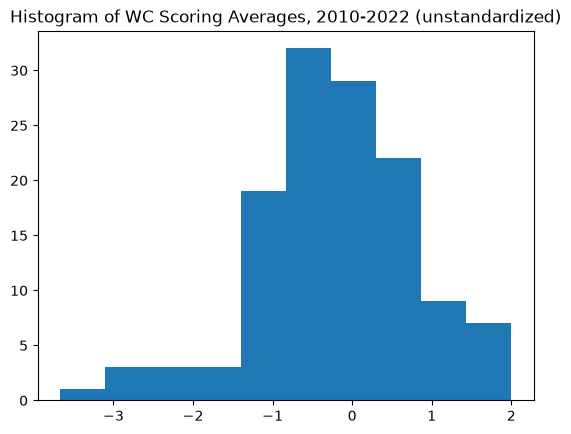

In [5]:
fig, ax = plt.subplots()
ax.hist(unstandardized_Y)
ax.set_title('Histogram of WC Scoring Averages, 2010-2022 (unstandardized)')
plt.show()

### Standardizing the Y vector
Inspecting the Y vector reveals that it has a mean slightly less than -0.2 and a standard deviation of approximately 0.98. That means that standardizing the data by subtracting the mean and dividing by the standard deviation only very slightly changes the values, but it's still best practice for modeling a continuous variable.

In [6]:
Y_mean = np.mean(unstandardized_Y)
Y_std_dev = np.std(unstandardized_Y)
# For simplicity, the standardized Y will be named simply Y
Y = (unstandardized_Y - Y_mean)/Y_std_dev
Y

array([ 0.88406598,  0.81582215, -0.8220296 ,  1.02055362, -0.8220296 ,
       -0.31020093,  0.54284686, -0.48081048, -0.31020093, -0.8220296 ,
        1.81023214,  0.40635921, -0.8220296 , -0.8220296 , -0.13959137,
        0.88406598, -3.55178252, -0.05428659, -0.05428659,  0.93281156,
        0.20162775, -0.48081048,  0.40635921,  1.73711376, -0.13959137,
       -0.31020093,  0.20162775, -0.48081048,  1.07904833,  0.20162775,
        0.20162775,  0.64033804,  0.20162775,  0.64033804, -1.84568694,
        0.81582215,  0.54284686, -0.09084578, -2.52812517,  0.71345642,
        1.8394795 ,  0.81582215, -0.13959137, -0.13959137,  0.20162775,
       -0.48081048,  1.22528509,  2.24894244, -0.13959137, -0.31020093,
       -1.84568694, -0.8220296 , -0.13959137, -1.16324871, -0.8220296 ,
        0.71345642,  1.81023214, -0.05428659, -1.16324871, -0.13959137,
       -0.8220296 ,  0.20162775, -0.05428659, -0.31020093,  1.02055362,
       -1.50446783, -1.16324871,  1.02055362, -0.48081048,  0.20

## Setup part 2: Creating the feature space

This notebook uses two primary features: the nation's FIFA Ranking Points at the time of the final rankings before the tournament began, and a metric calculating how many players on each roster were employed in one of the top 5 European professional leagues (the English Premier League, Spain's La Liga, the German Bundesliga, Italy's Serie A, or France's Ligue One). These features will be analyzed and combined in a variety of models.


### Importing FIFA Rankings Point data

Our historical FIFA Ranking data is pulled from a `csv` downloaded from kaggle, as documented in the `citations.txt`. As with the y-vector above, the data is first assembled into a Python list, then cast into a numpy array, which is visualized, then standardized.

In [7]:
fifa_rankings = pd.read_csv('fifa_ranking-2024-06-20.csv')
rpoints_list = []

rankings_2010 = fifa_rankings[fifa_rankings['rank_date']=='2010-05-26']
for team in team_list_2010:
    for i in range(rankings_2010.shape[0]):
        if rankings_2010.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2010.iloc[i, 3])

rankings_2014 = fifa_rankings[fifa_rankings['rank_date']=='2014-06-05']
for team in team_list_2014:
    for i in range(rankings_2014.shape[0]):
        if rankings_2014.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2014.iloc[i, 3])

rankings_2018 = fifa_rankings[fifa_rankings['rank_date']=='2018-06-07']
for team in team_list_2018:
    for i in range(rankings_2018.shape[0]):
        if rankings_2018.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2018.iloc[i, 3])

rankings_2022 = fifa_rankings[fifa_rankings['rank_date']=='2022-10-06']
for team in team_list_2022:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2022.iloc[i, 3])

len(rpoints_list)


128

In [9]:
unstandardized_RP = np.array(rpoints_list)
unstandardized_RP

array([ 821.  , 1076.  ,  886.  , 1611.  ,  887.  ,  888.  ,  856.  ,
        767.  , 1068.  , 1044.  , 1082.  ,  800.  ,  964.  ,  734.  ,
       1184.  ,  682.  ,  285.  ,  632.  ,  895.  , 1231.  ,  410.  ,
        883.  ,  820.  , 1249.  ,  947.  ,  777.  ,  860.  ,  392.  ,
       1565.  ,  866.  ,  957.  ,  899.  ,  858.  , 1175.  ,  526.  ,
       1074.  ,  873.  , 1242.  ,  558.  , 1026.  , 1137.  ,  762.  ,
        809.  ,  903.  ,  791.  , 1090.  ,  913.  , 1300.  ,  704.  ,
       1064.  ,  731.  ,  641.  , 1104.  ,  626.  ,  547.  ,  882.  ,
        981.  ,  640.  , 1189.  ,  893.  , 1485.  , 1149.  , 1035.  ,
       1147.  ,  457.  ,  465.  ,  649.  , 1018.  ,  686.  ,  708.  ,
       1274.  , 1126.  , 1198.  ,  718.  , 1241.  ,  908.  , 1125.  ,
       1051.  ,  945.  ,  618.  ,  884.  ,  751.  , 1558.  ,  989.  ,
       1431.  , 1199.  ,  880.  ,  544.  , 1298.  ,  571.  ,  910.  ,
       1051.  ,  986.  ,  521.  , 1183.  ,  838.  , 1439.89, 1728.47,
       1584.38, 1627

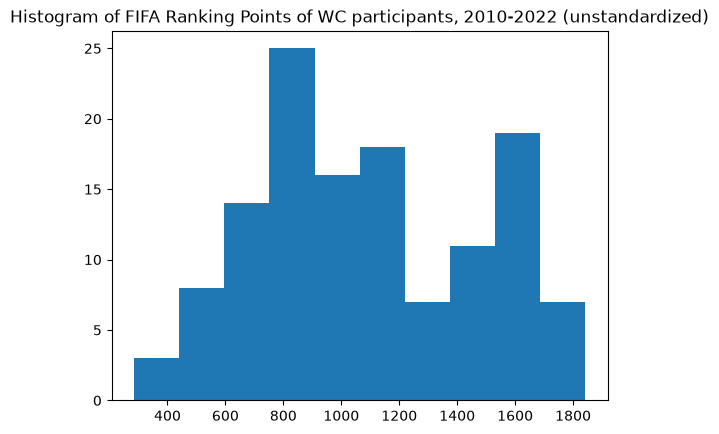

In [10]:
fig, ax = plt.subplots()
ax.hist(unstandardized_RP)
ax.set_title('Histogram of FIFA Ranking Points of WC participants, 2010-2022 (unstandardized)')
plt.show()

In [ ]:
RP_mean = np.mean(unstandardized_RP)
RP_std_dev = np.std(unstandardized_RP)
RP = (unstandardized_RP - RP_mean)/RP_std_dev
RP

array([-0.71916185, -0.04361966, -0.54696482,  1.37369435, -0.54431564,
       -0.54166645, -0.62644037, -0.86221784, -0.06481314, -0.12839358,
       -0.02772455, -0.77479474, -0.34032839, -0.94964095,  0.24249233,
       -1.08739857, -2.13912505, -1.21985783, -0.52312216,  0.36700402,
       -1.80797691, -0.55491238, -0.72181104,  0.41468936, -0.38536453,
       -0.83572599, -0.61584363, -1.85566224,  1.25183184, -0.59994852,
       -0.35887268, -0.51252542, -0.621142  ,  0.21864966, -1.50067144,
       -0.04891803, -0.58140423,  0.39614506, -1.41589752, -0.17607891,
        0.11798063, -0.87546377, -0.75095207, -0.50192868, -0.7986374 ,
       -0.00653107, -0.47543683,  0.54979779, -1.0291165 , -0.07540988,
       -0.95758851, -1.19601516,  0.03055752, -1.23575294, -1.44503856,
       -0.55756156, -0.29529224, -1.19866435,  0.25573825, -0.52842053,
        1.03989703,  0.14977085, -0.15223625,  0.14447248, -1.68346521,
       -1.66227173, -1.17482168, -0.19727239, -1.07680183, -1.01

### Aggregating T5League data

Fbref.com has aggregated roster-composition-by-league data easily accessible for the 2022 World Cup, but the data below for 2010, 2014, and 2018 were hand transcribed by examining the fbref page of each individual member of each World Cup roster. For the summer World Cups (2010, 2014, and 2018), the data reflects where a given player played in the season preceding the World Cup--i.e., the 2010 data reflects where players played in the 2009-2010 season. If a player appeared in multiple leagues during that season, they were counted as being a part of the "highest" league they played in, defined as English Premier League > La Liga > Bundesliga > Serie A > Ligue 1 > all other leagues.

As we compiled the data, we learned that World Cup roster sizes expanded in 2022: for the 2010, 2014, and 2018 tournaments, rosters were capped at 23 players; for the 2022 and 2026 tournaments, teams were allowed to roster 26 players. Therefore, the roster numbers below must be scaled by the total number of players on the roster to account for this change.

In [14]:
# These arrays need to be in the same order as the team lists for each respective year
# Data transcribed by hand from fbref.com

EPL_10 = np.array([3, 3, 6, 2, 3, 0, 6, 4, 23, 7, 0, 4, 1, 3, 0, 0,
                    0, 2, 2, 4, 2, 5, 2, 3, 4, 2, 0, 3, 3, 2, 7, 0])
La_Liga_10 = np.array([1, 3, 0, 4, 2, 2, 3, 1, 0, 3, 0, 1, 0, 0, 0, 1,
                        0, 0, 2, 2, 0, 2, 1, 5, 2, 0, 0, 0, 20, 0, 0, 3])
Bundesliga_10 = np.array([3, 1, 0, 2, 3, 1, 2, 2, 0, 1, 23, 3, 2, 0, 0, 1,
                            0, 1, 1, 5, 0, 2, 3, 3, 5, 4, 3, 0, 0, 8, 3, 0])
Serie_A_10 = np.array([1, 6, 1, 8, 1, 2, 0, 4, 0, 0, 0, 3, 2, 2, 23, 1,
                        0, 0, 0, 2, 0, 0, 1, 1, 3, 1, 2, 0, 0, 4, 0, 4])
Ligue_1_10 = np.array([4, 1, 0, 1, 6, 0, 3, 0, 0, 11, 0, 1, 0, 0, 0, 2,
                        0, 1, 0, 0, 0, 3, 0, 0, 0, 1, 3, 0, 0, 2, 1, 1])

EPL_14 = np.array([1, 2, 1, 11, 2, 6, 1, 1, 0, 1, 4, 2, 1, 22, 11, 4,
                    1, 2, 2, 1, 0, 2, 3, 1, 6, 5, 1, 0, 6, 1, 5, 3])
La_Liga_14 = np.array([5, 4, 0, 2, 0, 3, 3, 3, 2, 1, 0, 3, 0, 0, 3, 1,
                        0, 2, 0, 0, 0, 0, 0, 4, 0, 1, 6, 0, 14, 1, 0, 4])
Bundesliga_14 = np.array([0, 1, 1, 2, 6, 2, 2, 0, 2, 1, 4, 4, 1, 0, 0, 16,
                        1, 1, 0, 1, 0, 6, 4, 0, 3, 0, 1, 0, 1, 9, 4, 0])
Serie_A_14 = np.array([2, 7, 0, 1, 2, 3, 0, 4, 7, 0, 1, 3, 0, 0, 1, 2,
                        4, 6, 0, 0, 20, 2, 0, 0, 1, 1, 1, 0, 2, 5, 1, 5])
Ligue_1_14 = np.array([4, 2, 0, 1, 0, 2, 5, 0, 3, 0, 5, 1, 0, 0, 7, 0,
                        5, 0, 0, 0, 3, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1])

EPL_18 = np.array([0, 0, 5, 0, 1, 0, 4, 4, 5, 2, 3, 2, 1, 5, 1, 5,
                    0, 5, 3, 1, 6, 2, 2, 2, 12, 0, 1, 23, 3, 2, 3, 4])
La_Liga_18 = np.array([1, 2, 0, 5, 4, 0, 1, 17, 6, 0, 4, 0, 0, 3, 4, 2,
                        4, 2, 2, 3, 5, 1, 1, 0, 3, 0, 0, 0, 6, 2, 0, 1])
Bundesliga_18 = np.array([0, 0, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 4, 3, 1, 
                            0, 3, 15, 2, 0, 10, 3, 1, 2, 0, 0, 0, 1, 6, 3, 1])
Serie_A_18 = np.array([0, 0, 0, 5, 1, 0, 2, 1, 1, 0, 5, 1, 0, 2, 7, 2,
                        1, 4, 1, 1, 3, 5, 4, 1, 1, 0, 0, 0, 2, 1, 7, 3])
Ligue_1_18 = np.array([0, 0, 0, 1, 2, 0, 3, 0, 9, 0, 2, 0, 0, 2, 1, 1,
                        0, 0, 2, 0, 3, 1, 3, 0, 2, 0, 7, 0, 1, 2, 1, 7])

EPL_22 = np.array([0, 25, 6, 6, 5, 7, 1, 5, 2, 4, 5, 7, 5, 3, 10, 12,
                9, 3, 0, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 0, 5, 1])
La_Liga_22 = np.array([0, 0, 3, 2, 10, 4, 1, 5, 4, 2, 18, 4, 1, 4, 2, 5,
                    0, 2, 0, 1, 1, 3, 0, 1, 1, 0, 1, 0, 0, 0, 2, 6])
Bundesliga_22 = np.array([0, 1, 1, 2, 1, 6, 0, 6, 1, 20, 1, 3, 7, 0, 2, 0,
                        0, 2, 1, 2, 7, 5, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1])
Serie_A_22 = np.array([0, 0, 2, 2, 4, 2, 2, 3, 2, 0, 0, 2, 2, 3, 2, 3,
                    1, 4, 1, 9, 0, 4, 4, 1, 0, 0, 1, 0, 0, 0, 0, 11])
Ligue_1_22 = np.array([0, 0, 5, 1, 2, 1, 0, 6, 5, 0, 2, 3, 2, 0, 3, 2,
                    2, 0, 2, 2, 3, 1, 4, 0, 1, 0, 0, 0, 2, 1, 5, 0])


In [27]:
EPL_10_scaled = EPL_10/23
La_Liga_10_scaled = La_Liga_10/23
Bundesliga_10_scaled = Bundesliga_10/23
Serie_A_10_scaled = Serie_A_10/23
Ligue_1_10_scaled = Ligue_1_10/23

EPL_14_scaled = EPL_14/23
La_Liga_14_scaled = La_Liga_14/23
Bundesliga_14_scaled = Bundesliga_14/23
Serie_A_14_scaled = Serie_A_14/23
Ligue_1_14_scaled = Ligue_1_14/23

EPL_18_scaled = EPL_18/23
La_Liga_18_scaled = La_Liga_18/23
Bundesliga_18_scaled = Bundesliga_18/23
Serie_A_18_scaled = Serie_A_18/23
Ligue_1_18_scaled = Ligue_1_18/23

EPL_22_scaled = EPL_22/26
La_Liga_22_scaled = La_Liga_22/26
Bundesliga_22_scaled = Bundesliga_22/26
Serie_A_22_scaled = Serie_A_22/26
Ligue_1_22_scaled = Ligue_1_22/26

We'll create individual vectors for each of these five leagues, as well as a combined vector that aggregates the other five into a single sum, to see whether or not models perform better with more granular league data.

In [29]:
unstandardized_EPL = np.concatenate((EPL_10_scaled, EPL_14_scaled, EPL_18_scaled, EPL_22_scaled))
unstandardized_La_Liga = np.concatenate((La_Liga_10_scaled, La_Liga_14_scaled, La_Liga_18_scaled, La_Liga_22_scaled))
unstandardized_Bundesliga = np.concatenate((Bundesliga_10_scaled, Bundesliga_14_scaled, Bundesliga_18_scaled, Bundesliga_22_scaled))
unstandardized_Serie_A = np.concatenate((Serie_A_10_scaled, Serie_A_14_scaled, Serie_A_18_scaled, Serie_A_22_scaled))
unstandardized_Ligue_1 = np.concatenate((Ligue_1_10_scaled, Ligue_1_14_scaled, Ligue_1_18_scaled, Ligue_1_22_scaled))
unstandardized_t5league = unstandardized_EPL + unstandardized_La_Liga + unstandardized_Bundesliga + unstandardized_Serie_A + unstandardized_Ligue_1

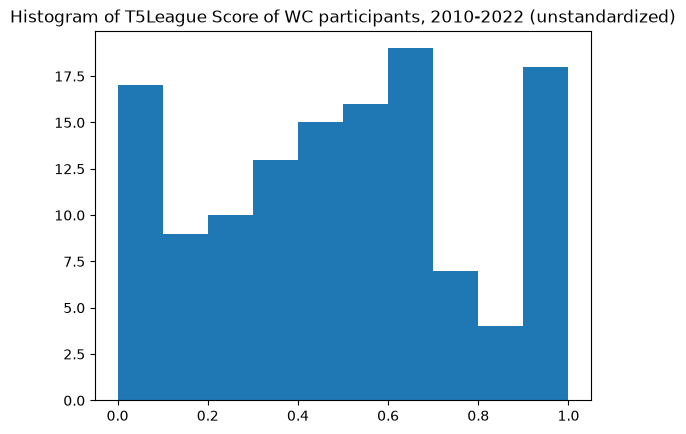

In [31]:
fig, ax = plt.subplots()
ax.hist(unstandardized_t5league)
ax.set_title('Histogram of T5League Score of WC participants, 2010-2022 (unstandardized)')
plt.show()

In [32]:
EPL_mean = np.mean(unstandardized_EPL)
EPL_std_dev = np.std(unstandardized_EPL)
EPL = (unstandardized_EPL - EPL_mean)/EPL_std_dev

La_Liga_mean = np.mean(unstandardized_La_Liga)
La_Liga_std_dev = np.std(unstandardized_La_Liga)
La_Liga = (unstandardized_La_Liga - La_Liga_mean)/La_Liga_std_dev

Bundesliga_mean = np.mean(unstandardized_Bundesliga)
Bundesliga_std_dev = np.std(unstandardized_Bundesliga)
Bundesliga = (unstandardized_Bundesliga - Bundesliga_mean)/Bundesliga_std_dev

Serie_A_mean = np.mean(unstandardized_Serie_A)
Serie_A_std_dev = np.std(unstandardized_Serie_A)
Serie_A = (unstandardized_Serie_A - Serie_A_mean)/Serie_A_std_dev

Ligue_1_mean = np.mean(unstandardized_Ligue_1)
Ligue_1_std_dev = np.std(unstandardized_Ligue_1)
Ligue_1 = (unstandardized_Ligue_1 - Ligue_1_mean)/Ligue_1_std_dev

t5league_mean = np.mean(unstandardized_t5league)
t5league_std_dev = np.std(unstandardized_t5league)
t5league = (unstandardized_t5league - t5league_mean)/t5league_std_dev

### Creating an Intercept Column

Finally, we'll create an array of 128 1s to serve as an intercept column for regressions, etc.

In [33]:
intercept=np.ones(128)

## Modeling